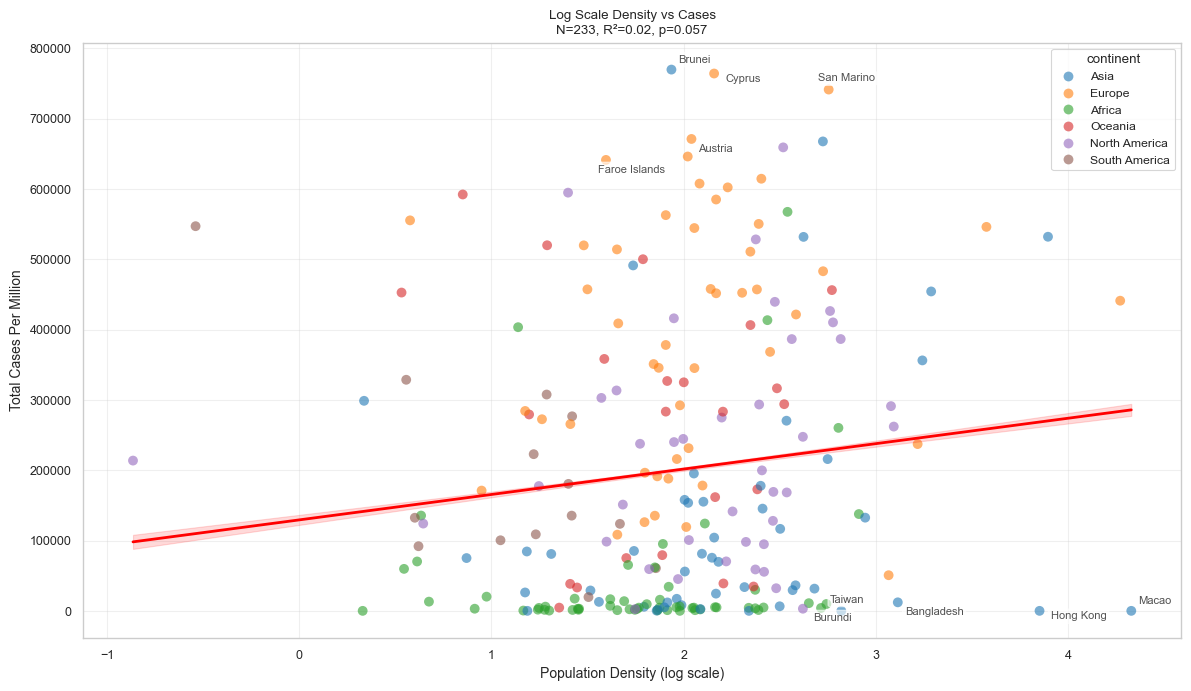

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
# 使用相对路径读取位于工作区根目录的 DataCleaning/compact_clean.csv
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = next((path for path in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (path / "DataCleaning" / "compact_clean.csv").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find DataCleaning/compact_clean.csv from the current notebook location.")
DATA_PATH = PROJECT_ROOT / "DataCleaning" / "compact_clean.csv"
OUTPUT_PATH = PROJECT_ROOT / "Insights" / "Population&Spread" / "log_plot_final.png"
df = pd.read_csv(DATA_PATH)
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").groupby("country", as_index=False).last()

required_cols = ["country", "population_density", "total_cases_per_million", "continent"]
clean_data = df[required_cols].dropna()
clean_data = clean_data[clean_data["population_density"] > 0]

clean_data["log_density"] = np.log10(clean_data["population_density"])
x = clean_data["log_density"]
y = clean_data["total_cases_per_million"]

slope, intercept, r, p, se = stats.linregress(x, y)
r2 = r**2
n = len(clean_data)

plt.figure(figsize=(12,7))

sns.scatterplot(data=clean_data, x="log_density", y=y, hue="continent", 
                alpha=0.6, s=50, edgecolor="none", palette="tab10")

x_range = np.linspace(x.min(), x.max(), 100)
y_pred = slope * x_range + intercept
ci = 1.96 * se * np.sqrt(1/n + (x_range - x.mean())**2 / np.sum((x-x.mean())**2))

plt.plot(x_range, y_pred, color="red", linewidth=2)
plt.fill_between(x_range, y_pred-ci, y_pred+ci, color="red", alpha=0.15)

clean_data["residual"] = y - (slope*x+intercept)
outliers = pd.concat([clean_data.nlargest(5,"residual"), clean_data.nsmallest(5,"residual")])
offsets = [(5,5), (8,-6), (-8,6), (5,-9), (-6,-9)]

for i, (_, row) in enumerate(outliers.iterrows()):
    ox, oy = offsets[i%len(offsets)]
    plt.annotate(row["country"], (row["log_density"], row["total_cases_per_million"]),
                 xytext=(ox,oy), textcoords="offset points", fontsize=8, alpha=0.8,
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6))

plt.xlabel("Population Density (log scale)")
plt.ylabel("Total Cases Per Million")
plt.title(f"Log Scale Density vs Cases\nN={n}, R²={r2:.2f}, p={p:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()